In [1]:
# ============================================================
# JPMorgan Chase Quantitative Research Virtual Experience
# Task 4 - FICO Score Quantization using Dynamic Programming
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [3]:
# ============================================================
# Keep Required Columns
# ============================================================

fico_data = df[
    [
        "fico_score",
        "default"
    ]
].copy()

In [4]:
fico_data = fico_data.sort_values(
    by="fico_score"
).reset_index(drop=True)

In [5]:
display(fico_data.head())

display(fico_data.tail())

,fico_score,default
0,408,0
1,409,1
2,418,1
3,425,1
4,438,1


,fico_score,default
9995,828,0
9996,831,0
9997,831,0
9998,835,0
9999,850,0


In [6]:
print("Unique FICO Scores :", fico_data["fico_score"].nunique())

Unique FICO Scores : 374


In [7]:
# ============================================================
# Convert Data to NumPy Arrays
# ============================================================

fico_scores = fico_data["fico_score"].to_numpy()

defaults = fico_data["default"].to_numpy()

num_records = len(fico_scores)

print(f"Number of borrowers : {num_records}")

Number of borrowers : 10000


In [8]:
# ============================================================
# Prefix Sum of Defaults
# ============================================================

prefix_defaults = np.zeros(num_records + 1, dtype=int)

for i in range(num_records):
    prefix_defaults[i + 1] = (
        prefix_defaults[i]
        + defaults[i]
    )

In [9]:
# ============================================================
# Log-Likelihood of a Bucket
# ============================================================

def bucket_log_likelihood(start, end):
    """
    Computes the log-likelihood for borrowers
    between indices [start, end].
    """

    n = end - start + 1

    k = (
        prefix_defaults[end + 1]
        - prefix_defaults[start]
    )

    if n == 0:
        return float("-inf")

    p = k / n

    # Prevent log(0)
    p = np.clip(p, 1e-10, 1 - 1e-10)

    return (
        k * np.log(p)
        + (n - k) * np.log(1 - p)
    )

In [10]:
print(bucket_log_likelihood(0, 50))

print(bucket_log_likelihood(100, 300))

print(bucket_log_likelihood(500, 900))

-28.95049155233798
-132.78115772876473
-272.6606241293785


In [11]:
# # ============================================================
# # Cost Matrix
# # ============================================================

# cost = np.full(
#     (num_records, num_records),
#     -np.inf
# )

# for start in range(num_records):

#     for end in range(start, num_records):

#         cost[start][end] = bucket_log_likelihood(
#             start,
#             end
#         )

# print("Cost matrix built successfully.")

In [12]:
# ============================================================
# Group Borrowers by Unique FICO Scores
# ============================================================

fico_summary = (
    fico_data
    .groupby("fico_score")
    .agg(
        borrowers=("default", "count"),
        defaults=("default", "sum")
    )
    .reset_index()
)

display(fico_summary.head())

print("Unique FICO Scores:", len(fico_summary))

,fico_score,borrowers,defaults
0,408,1,0
1,409,1,1
2,418,1,1
3,425,1,1
4,438,1,1


Unique FICO Scores: 374


In [13]:
# Prefix sums for efficient interval queries
borrowers_prefix = np.concatenate(
    ([0], fico_summary["borrowers"].cumsum().to_numpy())
)

defaults_prefix = np.concatenate(
    ([0], fico_summary["defaults"].cumsum().to_numpy())
)

num_scores = len(fico_summary)

print(f"Unique FICO scores: {num_scores}")

Unique FICO scores: 374


In [14]:
# ============================================================
# Bucket Log-Likelihood
# ============================================================

def interval_log_likelihood(left, right):

    total = (
        borrowers_prefix[right + 1]
        - borrowers_prefix[left]
    )

    defaults = (
        defaults_prefix[right + 1]
        - defaults_prefix[left]
    )

    if total == 0:
        return -np.inf

    p = defaults / total

    p = np.clip(
        p,
        1e-10,
        1 - 1e-10
    )

    return (
        defaults * np.log(p)
        + (total - defaults)
        * np.log(1 - p)
    )

Dynamic Programming

In [15]:
# ============================================================
# Number of Buckets
# ============================================================

NUM_BUCKETS = 10

In [16]:
# ============================================================
# Dynamic Programming Tables
# ============================================================

dp = np.full(
    (NUM_BUCKETS + 1, num_scores),
    -np.inf
)

parent = np.full(
    (NUM_BUCKETS + 1, num_scores),
    -1,
    dtype=int
)

In [17]:
# ============================================================
# Base Case
# ============================================================

for end in range(num_scores):
    dp[1][end] = interval_log_likelihood(0, end)

In [18]:
# ============================================================
# Fill DP Table
# ============================================================

for buckets in range(2, NUM_BUCKETS + 1):

    print(f"Computing {buckets} buckets...")

    for end in range(buckets - 1, num_scores):

        best_score = -np.inf
        best_split = -1

        for split in range(buckets - 2, end):

            score = (
                dp[buckets - 1][split]
                + interval_log_likelihood(split + 1, end)
            )

            if score > best_score:
                best_score = score
                best_split = split

        dp[buckets][end] = best_score
        parent[buckets][end] = best_split

print("Dynamic Programming Completed!")

Computing 2 buckets...
Computing 3 buckets...
Computing 4 buckets...
Computing 5 buckets...
Computing 6 buckets...
Computing 7 buckets...
Computing 8 buckets...
Computing 9 buckets...
Computing 10 buckets...
Dynamic Programming Completed!


In [19]:

# ============================================================
# Recover Optimal Boundaries
# ============================================================

boundaries = []

current = num_scores - 1

for bucket in range(NUM_BUCKETS, 1, -1):

    split = parent[bucket][current]

    boundaries.append(
        fico_summary.iloc[split]["fico_score"]
    )

    current = split

boundaries.reverse()

print("Optimal FICO Boundaries:")
print(boundaries)

Optimal FICO Boundaries:
[520, 552, 580, 611, 649, 696, 732, 752, 753]


Assign Ratings

In [20]:
# ============================================================
# Assign Ratings
# ============================================================

def assign_rating(fico_score, boundaries):
    """
    Assign ratings such that:
    Rating 1 = Best Credit
    Rating 10 = Highest Risk
    """

    bucket = 1

    for boundary in boundaries:
        if fico_score <= boundary:
            break
        bucket += 1

    # Reverse the numbering
    return len(boundaries) + 2 - bucket

In [21]:
fico_data["Rating"] = fico_data["fico_score"].apply(
    lambda x: assign_rating(x, boundaries)
)

display(fico_data.head())

,fico_score,default,Rating
0,408,0,10
1,409,1,10
2,418,1,10
3,425,1,10
4,438,1,10


Probability of Default by Rating

In [22]:
# ============================================================
# Rating Summary
# ============================================================

rating_summary = (
    fico_data
    .groupby("Rating")
    .agg(
        Borrowers=("default", "count"),
        Defaults=("default", "sum")
    )
)

rating_summary["Probability_of_Default"] = (
    rating_summary["Defaults"]
    / rating_summary["Borrowers"]
)

rating_summary = rating_summary.sort_index()

display(rating_summary)

,Borrowers,Defaults,Probability_of_Default
Rating,,,
1,242,5,0.020661
2,8,3,0.375000
3,303,5,0.016502
4,1104,64,0.057971
5,2609,256,0.098122
6,2465,402,0.163083
7,1561,381,0.244074
8,911,307,0.336992
9,496,229,0.461694


Probability of Default by Rating

In [23]:
# ============================================================
# Probability of Default for Each Rating
# ============================================================

rating_summary = (

    fico_data

    .groupby("Rating")

    .agg(

        Borrowers=("default", "count"),

        Defaults=("default", "sum")

    )

)

rating_summary["Probability_of_Default"] = (

    rating_summary["Defaults"]

    / rating_summary["Borrowers"]

)

display(rating_summary)

,Borrowers,Defaults,Probability_of_Default
Rating,,,
1,242,5,0.020661
2,8,3,0.375000
3,303,5,0.016502
4,1104,64,0.057971
5,2609,256,0.098122
6,2465,402,0.163083
7,1561,381,0.244074
8,911,307,0.336992
9,496,229,0.461694


Create Rating Map

In [24]:
# ============================================================
# Rating Map
# ============================================================

rating_map = []

all_bounds = [fico_data["fico_score"].min()] + boundaries + [fico_data["fico_score"].max()]

for i in range(len(all_bounds) - 1):

    rating = len(boundaries) + 1 - i

    rating_map.append({
        "Rating": rating,
        "FICO Range": f"{all_bounds[i]} - {all_bounds[i+1]}"
    })

rating_map = pd.DataFrame(rating_map)

display(rating_map.sort_values("Rating"))

,Rating,FICO Range
9,1,753 - 850
8,2,752 - 753
7,3,732 - 752
6,4,696 - 732
5,5,649 - 696
4,6,611 - 649
3,7,580 - 611
2,8,552 - 580
1,9,520 - 552
0,10,408 - 520


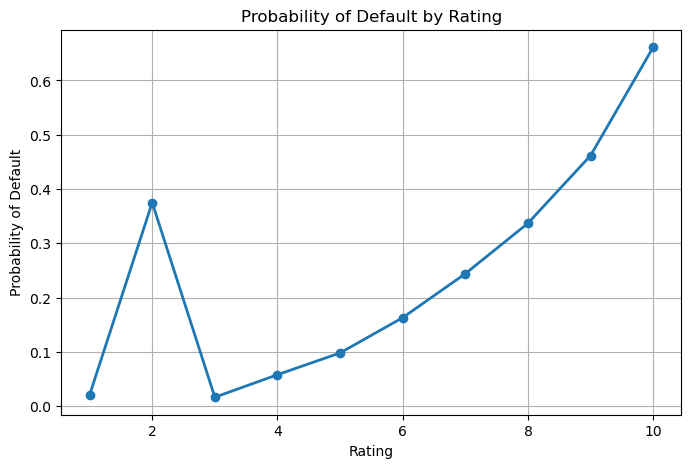

In [25]:
# ============================================================
# Probability of Default by Rating
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    rating_summary.index,
    rating_summary["Probability_of_Default"],
    marker="o",
    linewidth=2
)

plt.xlabel("Rating")

plt.ylabel("Probability of Default")

plt.title("Probability of Default by Rating")

plt.grid(True)

plt.show()

In [26]:
# ============================================================
# Predict Rating and PD
# ============================================================

def predict_rating(fico_score):

    rating = assign_rating(fico_score, boundaries)

    pd_value = rating_summary.loc[
        rating,
        "Probability_of_Default"
    ]

    print(f"FICO Score            : {fico_score}")
    print(f"Assigned Rating       : {rating}")
    print(f"Probability of Default: {pd_value:.2%}")

In [27]:
predict_rating(720)

FICO Score            : 720
Assigned Rating       : 4
Probability of Default: 5.80%


In [28]:
print(rating_map.sort_values("Rating"))

   Rating FICO Range
9       1  753 - 850
8       2  752 - 753
7       3  732 - 752
6       4  696 - 732
5       5  649 - 696
4       6  611 - 649
3       7  580 - 611
2       8  552 - 580
1       9  520 - 552
0      10  408 - 520


In [29]:
print(rating_summary)

        Borrowers  Defaults  Probability_of_Default
Rating                                             
1             242         5                0.020661
2               8         3                0.375000
3             303         5                0.016502
4            1104        64                0.057971
5            2609       256                0.098122
6            2465       402                0.163083
7            1561       381                0.244074
8             911       307                0.336992
9             496       229                0.461694
10            301       199                0.661130
